# Logistic Regression

## Prepare the Notebook
> Import the needed libraries, and load the data 

In [15]:
# Import the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
import sys
# Import the related function of the utils.py file
sys.path.append("D:\Data science project\Data science\Codveda-internship\Level 2")
from Level_2.utils import *
warnings.filterwarnings('ignore')

In [16]:
### Load the data
# Load the data
reg_df = pd.read_csv(r"D:\Data science project\Data science\Codveda-internship\Level 2\Task 1\models_data.csv")

# preview the data
print("Real estates data:\n")
reg_df

Real estates data:



,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,4.531093,15.701671,11.170578,False,False,False
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,0,5.986452,18.006740,12.020288,False,False,True
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,1,0,0,4.532599,16.366829,11.834229,False,False,False
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,0,5.529429,16.369399,10.839970,False,False,False
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,5.344342,15.981244,10.636903,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,5.178802,15.552110,10.373308,False,False,False
852,Jade Park,1,0,1,1,0,0,1,0,1,...,0,0,0,0,6.539586,17.045999,10.506413,False,True,False
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,0,5.141664,15.629847,10.488183,False,False,False
854,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,5.335517,15.596041,10.260524,False,False,False


#### Add Is apartment variable

In [17]:
reg_df["Is apartment"] = 1 - reg_df[["propertySubType_Retail","propertySubType_Others(very rare)","propertySubType_Office","propertySubType_Attached Houses"]].sum(axis = 1) ### Restore the Apartment dummy variable
# drop the original propertySubType column except Apartment dummy variable
reg_df.drop(columns = ["propertySubType_Retail","propertySubType_Others(very rare)","propertySubType_Office","propertySubType_Attached Houses"], inplace = True, axis = 1)

reg_df

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,city_North Coast,city_Old Cairo,propertyCategory_Commercial,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is apartment
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,1,0,0,4.531093,15.701671,11.170578,False,False,False,1
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,1
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,0,1,4.532599,16.366829,11.834229,False,False,False,0
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,1
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,1,0,0,5.344342,15.981244,10.636903,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,1,0,0,5.178802,15.552110,10.373308,False,False,False,1
852,Jade Park,1,0,1,1,0,0,1,0,1,...,0,0,0,6.539586,17.045999,10.506413,False,True,False,1
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,5.141664,15.629847,10.488183,False,False,False,1
854,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,1,0,0,5.335517,15.596041,10.260524,False,False,False,1


In [18]:
#### Check if commercial category, and Is apartments are opposite
reg_df.groupby("propertyCategory_Commercial")["Is apartment"].sum()

propertyCategory_Commercial
0    652
1      0
Name: Is apartment, dtype: int64

> Drop the commercial category feature

In [19]:
reg_df.drop("propertyCategory_Commercial", axis = 1, inplace = True)
reg_df

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,city_New Cairo,city_North Coast,city_Old Cairo,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is apartment
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,1,0,4.531093,15.701671,11.170578,False,False,False,1
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,1
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,0,0,4.532599,16.366829,11.834229,False,False,False,0
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,1
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,1,0,5.344342,15.981244,10.636903,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,1,0,5.178802,15.552110,10.373308,False,False,False,1
852,Jade Park,1,0,1,1,0,0,1,0,1,...,0,0,0,6.539586,17.045999,10.506413,False,True,False,1
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,5.141664,15.629847,10.488183,False,False,False,1
854,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,1,0,5.335517,15.596041,10.260524,False,False,False,1


## Non outliers regression

### Set x, and y

In [20]:
outliers_list = reg_df.columns[reg_df.columns.str.startswith("Is")].drop("Is apartment").tolist() # the outliers bool columns
drop_cols = outliers_list + ["name"] # the columns to drop
x, y = set_xy(reg_df, "Is apartment", False, outliers_list, drop_cols)

print(f"Features shape: {x.shape}\n")
print(f"Target values(first 5 rows):\n{y.head()}")

Features shape: (732, 26)

Target values(first 5 rows):
0    1
2    0
3    1
4    1
5    1
Name: Is apartment, dtype: int64


In [21]:
### Split the data into train and test sets
x_train, x_test, y_train, y_test = split_data(x, y, test_size=0.2)

print(f"X_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (585, 26), y_train shape: (585,)
X_test shape: (147, 26), y_test shape: (147,)


### Check VIFs values

In [22]:
def vifs_scores(x):
    for col in x.columns:
        vif = variance_inflation_factor(x.values, x.columns.get_loc(col))
        print(f"VIF for {col}: {vif}")
vifs_scores(x_train)

VIF for has_main_facilities: 9.960539566286599
VIF for has_security_features: 55.22508287261887
VIF for has_parking_safety: 3.1390169118333264
VIF for has_building_facilities: 5.337912958903524
VIF for has_other_features: 11.410197940101922
VIF for HighFloor: 1.639607487639279
VIF for MidFloor: 2.5131978647399613
VIF for has_modern: 8.843629173360766
VIF for has_facilities: 6.203547175290882
VIF for has_green_view: 7.61252418534432
VIF for has_water_feature: 13.910870863095033
VIF for Bedroom_1: 6.906381866985147
VIF for Bedroom_2: 8.94110296773935
VIF for Bedroom_3: 26.042677519204954
VIF for Bedroom_above 3: 10.729157832955721
VIF for Bathroom_1: 1.6928011879142155
VIF for Bathroom_2: 2.6257787023261008
VIF for Bathroom_above 2: 3.8265962500108253
VIF for city_Mansoura: 5.6153689489682295
VIF for city_New Administrative Capital: 8.959737983665928
VIF for city_New Cairo: 1.667509133507148
VIF for city_North Coast: 14.610338923951174
VIF for city_Old Cairo: 4.000552410940888
VIF for lo

In [23]:
collinearity_features =  ["log(price/sqm)", "log(price)"] # the perfect collinearity features
x.drop(columns= collinearity_features, axis = 1, inplace=True) # drop them

x["has_full_facilities"] = x["has_main_facilities"] * x["has_building_facilities"]  # combine the two features

x.drop(columns=["has_building_facilities", "has_main_facilities"], axis=1, inplace=True) # drop the old ones


x_train, x_test, y_train, y_test = split_data(x, y, test_size=0.2)

vifs_scores(x_train)

VIF for has_security_features: 49.18605542922943
VIF for has_parking_safety: 2.3010092187309925
VIF for has_other_features: 9.870961129888434
VIF for HighFloor: 1.5557592276801908
VIF for MidFloor: 2.50093625856739
VIF for has_modern: 8.059087505438796
VIF for has_facilities: 5.4112960315990115
VIF for has_green_view: 5.420565743833799
VIF for has_water_feature: 11.313246159800167
VIF for Bedroom_1: 6.464412858664135
VIF for Bedroom_2: 8.790198028377946
VIF for Bedroom_3: 22.93027583995985
VIF for Bedroom_above 3: 8.52910215838559
VIF for Bathroom_1: 1.386907733715011
VIF for Bathroom_2: 2.6051916168039386
VIF for Bathroom_above 2: 3.4006528072852227
VIF for city_Mansoura: 4.3009147546341255
VIF for city_New Administrative Capital: 7.805336979022252
VIF for city_New Cairo: 1.4184768957026073
VIF for city_North Coast: 13.637849863716582
VIF for city_Old Cairo: 3.9523552629407437
VIF for log(sqm): 82.1842378223326
VIF for has_full_facilities: 3.453495440509077


> I should drop price/sqm, price to prevent high values, and combine has_main_facilities, with building facilities

### Check the mostly constant features

In [24]:
# Check if both non-commercial, and commercial properties unique values have above 20 row 
def exclude_low_variance_features(x, y):
    """This function returns the imbalanced, and constant features

    Args:
        x (array_like): The x matrix 
        y (array_like): The y vector

    Returns:
        ExcludedFeatures: The excluded variables which mostly constant, or constant
    """
    non_outliers_df = x.join(y)
    excluded_vars = []
    for feature in x.columns:
        groupby_df = non_outliers_df.groupby(y.name)[feature].sum()
        statement = (groupby_df >= 20).sum()
        if statement != 2:
            excluded_vars.append(feature)
            print(f"The feature '{feature}' is excluded due to having less than 20 rows in one of the groups.")
    return excluded_vars
excluded_features = exclude_low_variance_features(x_train, y_train)
x.drop(excluded_features, axis=1, inplace=True)

The feature 'has_parking_safety' is excluded due to having less than 20 rows in one of the groups.
The feature 'HighFloor' is excluded due to having less than 20 rows in one of the groups.
The feature 'MidFloor' is excluded due to having less than 20 rows in one of the groups.
The feature 'has_modern' is excluded due to having less than 20 rows in one of the groups.
The feature 'has_water_feature' is excluded due to having less than 20 rows in one of the groups.
The feature 'Bedroom_1' is excluded due to having less than 20 rows in one of the groups.
The feature 'Bedroom_2' is excluded due to having less than 20 rows in one of the groups.
The feature 'Bedroom_above 3' is excluded due to having less than 20 rows in one of the groups.
The feature 'Bathroom_1' is excluded due to having less than 20 rows in one of the groups.
The feature 'Bathroom_2' is excluded due to having less than 20 rows in one of the groups.
The feature 'Bathroom_above 2' is excluded due to having less than 20 rows 

### Add interactions

In [25]:
### Preview the train x data
x_train

,has_security_features,has_parking_safety,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,has_water_feature,Bedroom_1,...,Bathroom_1,Bathroom_2,Bathroom_above 2,city_Mansoura,city_New Administrative Capital,city_New Cairo,city_North Coast,city_Old Cairo,log(sqm),has_full_facilities
798,1,0,1,0,1,0,0,1,1,1,...,0,0,0,0,0,0,1,0,4.811371,0
296,1,0,1,0,1,1,1,0,0,1,...,0,0,0,0,0,0,1,0,4.555665,0
398,1,0,1,0,0,0,0,1,1,0,...,0,0,0,0,0,0,1,0,5.288822,0
306,1,0,1,0,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,5.141664,0
518,1,0,1,0,1,1,1,0,0,0,...,0,0,0,0,0,0,1,0,4.934330,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,0,1,0,0,1,0,1,0,0,0,...,0,1,0,0,1,0,0,0,5.424950,1
125,1,0,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,1,0,5.525453,0
319,1,0,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,1,0,5.478219,0
513,1,0,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,5.529429,0


In [26]:
#### Add some interactions
x["log(sqm)_centered"] = x["log(sqm)"] - x["log(sqm)"].mean()

x["other features * log(sqm)_centered"] = x["has_other_features"] * x["log(sqm)_centered"]
x["has_facilities * log(sqm)_centered"] = x["has_full_facilities"] * x["log(sqm)_centered"]
x["has_facilities * has_green_view"] = x["has_full_facilities"] * x["has_green_view"]

### Drop the original columns
x.drop(columns=["log(sqm)","has_security_features"], inplace=True)

x

,has_other_features,has_facilities,has_green_view,Bedroom_3,has_full_facilities,log(sqm)_centered,other features * log(sqm)_centered,has_facilities * log(sqm)_centered,has_facilities * has_green_view
0,1,1,0,0,0,-0.730999,-0.730999,-0.0,0
2,1,0,1,0,0,-0.729492,-0.729492,-0.0,0
3,0,1,1,1,0,0.267338,0.000000,0.0,0
4,1,0,1,1,0,0.082250,0.082250,0.0,0
5,1,0,0,0,0,-0.327618,-0.327618,-0.0,0
...,...,...,...,...,...,...,...,...,...
849,0,0,0,1,0,-0.394557,-0.000000,-0.0,0
850,1,1,0,0,0,-0.426524,-0.426524,-0.0,0
851,1,0,1,1,0,-0.083290,-0.083290,-0.0,0
853,1,1,1,1,0,-0.120428,-0.120428,-0.0,0


- Now we can perform the model selection method

In [27]:
x_train, x_test, y_train, y_test = split_data(x, y, test_size=0.2)
train_df = x_train.join(y_train)
logit_model, removed_vars, _ = general_to_specific(train_df, "Is apartment", x_train.columns, reg_type="Logistic")

Optimization terminated successfully.
         Current function value: 0.311778
         Iterations 7
Removing has_other_features due to corrected p=0.7861
Optimization terminated successfully.
         Current function value: 0.311840
         Iterations 7
Removing has_facilities * has_green_view due to corrected p=0.7738
Optimization terminated successfully.
         Current function value: 0.311910
         Iterations 7
Removing has_facilities due to corrected p=0.4461
Optimization terminated successfully.
         Current function value: 0.312514
         Iterations 7
Removing has_full_facilities due to corrected p=0.5567
Optimization terminated successfully.
         Current function value: 0.312799
         Iterations 7
Removing has_green_view due to corrected p=0.2562
Optimization terminated successfully.
         Current function value: 0.313903
         Iterations 7
Removing log(sqm)_centered due to corrected p=0.0614
Optimization terminated successfully.
         Current func

### Evaluation

In [28]:
logit_sklearn_model = LogisticRegression(random_state=42).fit(x_train, y_train)

logit_sklearn_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


ROC AUC: 0.8502805049088359
              precision    recall  f1-score   support

           0       0.79      0.48      0.59        23
           1       0.91      0.98      0.94       124

    accuracy                           0.90       147
   macro avg       0.85      0.73      0.77       147
weighted avg       0.89      0.90      0.89       147

Cross validation scores (accuracy): [0.8974359  0.88888889 0.90598291 0.88034188 0.84615385]


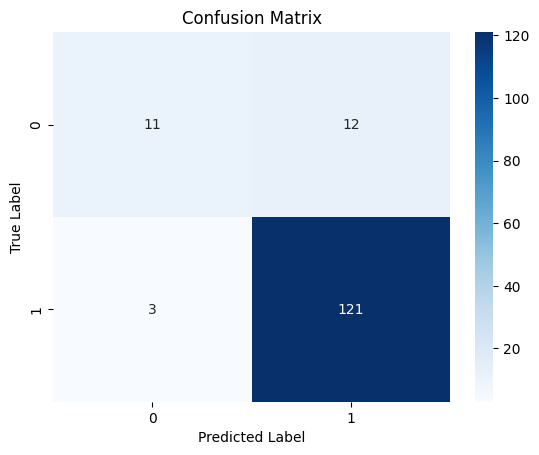

In [29]:
y_pred_prob = logit_sklearn_model.predict_proba(x_test)[:,1]
y_pred = (y_pred_prob > 0.5).astype(int)

def model_performance(y_test, y_pred_prob, y_pred, model, y_train, x_train):
    """Evaluate the performance of the model using various metrics.

    Args:
        y_test (array-like): True labels.
        y_pred_prob (array-like): Predicted probabilities for the positive class.
        y_pred (array-like): Predicted labels.
        model: The trained model.
        y_train (array-like): Training labels.
        x_train (array-like): Training features.
    """
    confusion_matrix_ = confusion_matrix(y_test, y_pred)
    sns.heatmap(confusion_matrix_, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')

    print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
    print(classification_report(y_test, y_pred))
    print("Cross validation scores (accuracy):", cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy'))

model_performance(y_test, y_pred_prob, y_pred, logit_sklearn_model, y_train, x_train)

- The model performance shows a very good values, but there are a big difference between class 0, and class 1 due to the imbalance. Stable model accuracy

> But we can get the best threshold that balance between precision, and recall

The best threshold is: 0.7842916955846342


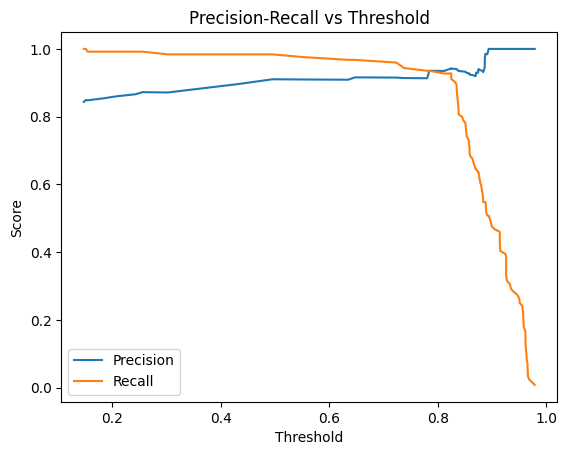

In [30]:
def precision_recall_graph(y_test, y_pred_prob):
    """Plot the precision-recall curve.

    Args:
        y_test (array-like): True labels.
        y_pred_prob (array-like): Predicted probabilities for the positive class.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
    ### The interaction threshold
    balance = np.abs(precisions - recalls)

    best_threshold = thresholds[np.argmin(balance)]
    print(f"The best threshold is: {best_threshold}")
    
    sns.lineplot(x=thresholds, y=precisions[:-1], label='Precision')
    sns.lineplot(x=thresholds, y=recalls[:-1], label='Recall')

    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision-Recall vs Threshold')
    plt.legend()
    plt.show()
    return best_threshold

best_threshold = precision_recall_graph(y_test, y_pred_prob)

- The best threshold is between 0.6, and 0.8

ROC AUC: 0.8502805049088359
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        23
           1       0.94      0.94      0.94       124

    accuracy                           0.89       147
   macro avg       0.79      0.79      0.79       147
weighted avg       0.89      0.89      0.89       147

Cross validation scores (accuracy): [0.8974359  0.88888889 0.90598291 0.88034188 0.84615385]


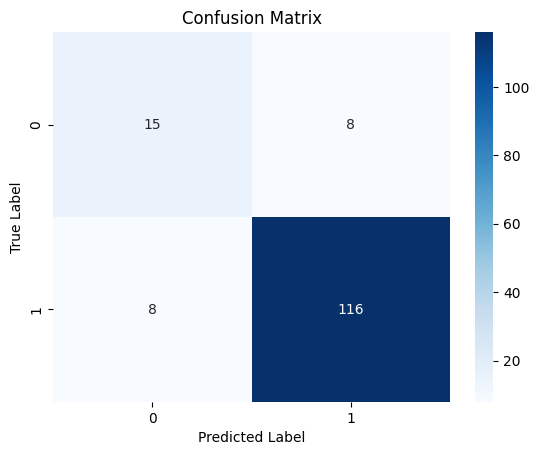

In [31]:
y_pred = (y_pred_prob >= best_threshold).astype(int)

model_performance(y_test, y_pred_prob, y_pred, logit_sklearn_model, y_train, x_train)

- The model is better than before, with low variances between recall, and precisions, unstable accuracy, and High ROC value

### Experiment on RandomForest, and Decision Tree

#### Random forest

ROC AUC: 0.95617110799439
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        23
           1       0.98      0.96      0.97       124

    accuracy                           0.95       147
   macro avg       0.89      0.91      0.90       147
weighted avg       0.95      0.95      0.95       147

Cross validation scores (accuracy): [0.95726496 0.94017094 0.95726496 0.94871795 0.91452991]


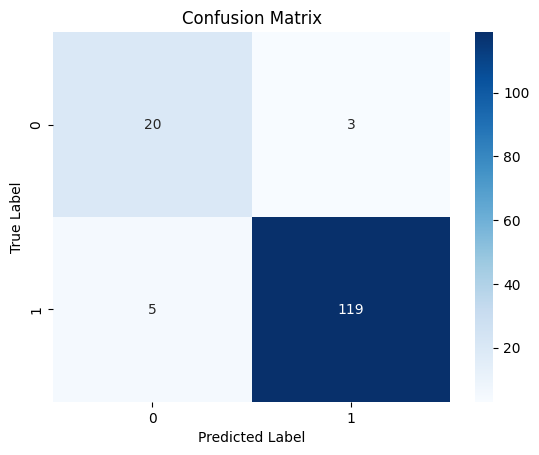

In [32]:
rf_model = RandomForestClassifier(random_state=42).fit(x_train, y_train) # fit the model

y_pred_prob = rf_model.predict_proba(x_test)[:,1] # get the model predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int) # fitted values

model_performance(y_test, y_pred_prob, y_pred, rf_model, y_train, x_train) # model performance

The best threshold is: 0.35


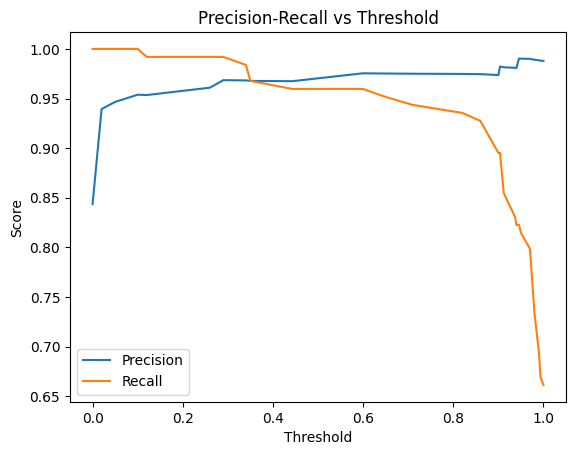

In [33]:
### Best threshold

best_threshold = precision_recall_graph(y_test, y_pred_prob)

ROC AUC: 0.95617110799439
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        23
           1       0.97      0.97      0.97       124

    accuracy                           0.95       147
   macro avg       0.90      0.90      0.90       147
weighted avg       0.95      0.95      0.95       147

Cross validation scores (accuracy): [0.95726496 0.94017094 0.95726496 0.94871795 0.91452991]


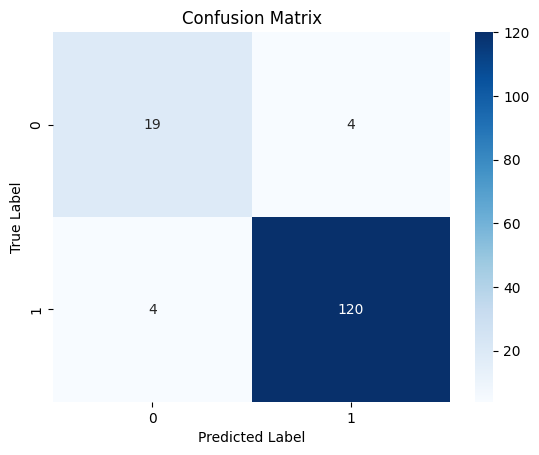

In [34]:
y_pred = (y_pred_prob >= best_threshold).astype(int) ## New predicated values

model_performance(y_test, y_pred_prob, y_pred, rf_model, y_train, x_train) # Model performance

> Random forest model shows high f1 scores, low variance between them, high accuracy. Stable accuracy

#### Decision Tree

ROC AUC: 0.8942847124824684
              precision    recall  f1-score   support

           0       0.76      0.83      0.79        23
           1       0.97      0.95      0.96       124

    accuracy                           0.93       147
   macro avg       0.86      0.89      0.88       147
weighted avg       0.93      0.93      0.93       147

Cross validation scores (accuracy): [0.94871795 0.91452991 0.95726496 0.92307692 0.91452991]


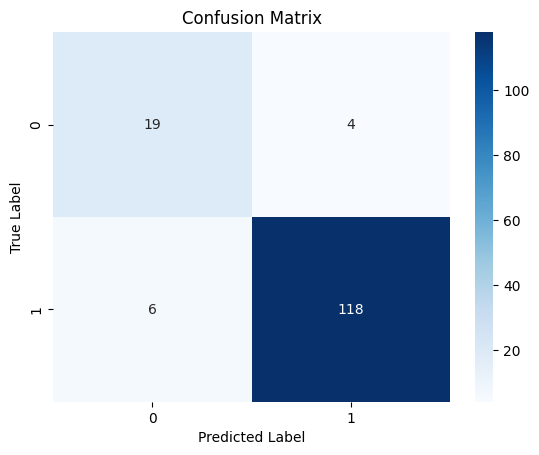

In [35]:
dt_model = DecisionTreeClassifier(random_state=42).fit(x_train, y_train) # fit the model

y_pred_prob = dt_model.predict_proba(x_test)[:,1] # get the model predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int) # fitted values

model_performance(y_test, y_pred_prob, y_pred, dt_model, y_train, x_train) # model performance

The best threshold is: 0.5


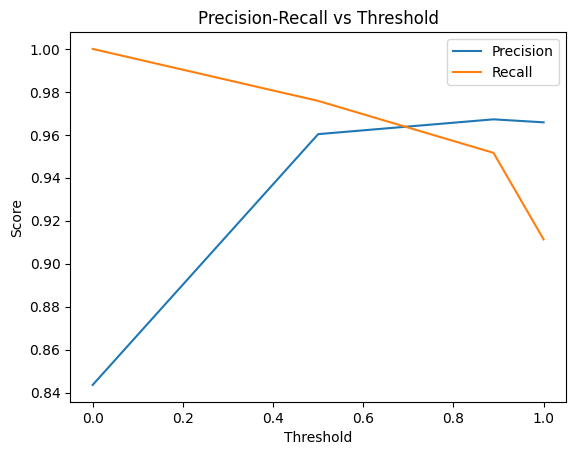

In [36]:
#### Best threshold

best_threshold = precision_recall_graph(y_test=y_test, y_pred_prob=y_pred_prob)

ROC AUC: 0.8942847124824684
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        23
           1       0.96      0.98      0.97       124

    accuracy                           0.95       147
   macro avg       0.91      0.88      0.89       147
weighted avg       0.94      0.95      0.94       147

Cross validation scores (accuracy): [0.94871795 0.91452991 0.95726496 0.92307692 0.91452991]


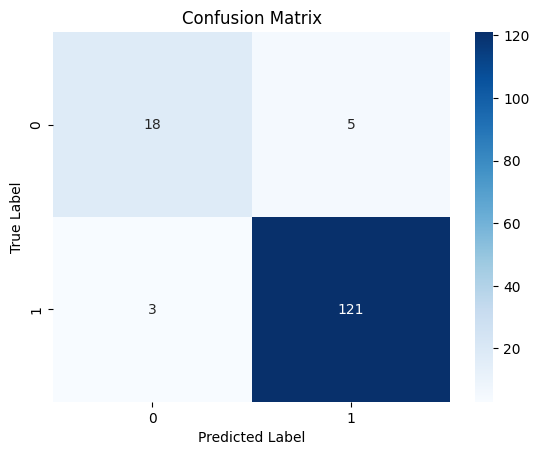

In [37]:
y_pred = (y_pred_prob >= best_threshold).astype(int)

model_performance(y_test, y_pred_prob, y_pred, dt_model, y_train, x_train) # model performance

- Decision Tree shows a high accuracy, no variance between precision, and recall. Slightly stable, but Random forest still the best performance

## Outliers regression

In [38]:
## Pick the outliers values

x,y = set_xy(reg_df, "Is apartment", True, outliers_list, drop_cols)

outliers_df = x.join(y)

outliers_df

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,Bathroom_above 2,city_Mansoura,city_New Administrative Capital,city_New Cairo,city_North Coast,city_Old Cairo,log(sqm),log(price),log(price/sqm),Is apartment
1,0,0,0,0,1,1,0,0,1,1,...,1,0,0,0,0,0,5.986452,18.006740,12.020288,1
12,0,0,0,0,1,1,0,0,1,1,...,1,0,0,0,0,0,5.986452,18.014245,12.027793,1
17,1,1,0,1,0,0,1,0,1,0,...,0,0,0,1,0,0,5.201090,17.351414,12.150323,0
23,1,1,0,1,0,0,0,0,1,0,...,0,0,0,1,0,0,5.173434,17.400029,12.226595,0
24,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,4.166665,16.523961,12.357295,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,1,0,0,1,1,0,1,0,1,...,0,0,0,1,0,0,3.113515,14.315680,11.202164,1
844,1,1,0,1,0,0,0,0,1,0,...,1,1,0,0,0,0,6.414933,16.693022,10.278089,0
846,0,1,0,0,1,1,0,1,0,1,...,0,0,0,1,0,0,2.708050,14.004477,11.296426,1
852,1,0,1,1,0,0,1,0,1,0,...,0,0,1,0,0,0,6.539586,17.045999,10.506413,1
